# Task 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

**Load Dataset**

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (1797, 64)
Label shape: (1797,)


**Preprocessing**

In [3]:
X = X / 16.0  # pixel values range from 0–16

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

**Train-Test Split**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1347, 64)
Test shape: (450, 64)


**Neural Network**

In [5]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dense(y_encoded.shape[1], activation='softmax')
])

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [7]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    verbose=1
)

Epoch 1/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.2888 - loss: 2.1224 - val_accuracy: 0.4889 - val_loss: 1.8888
Epoch 2/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5970 - loss: 1.6251 - val_accuracy: 0.6259 - val_loss: 1.3843
Epoch 3/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7419 - loss: 1.1109 - val_accuracy: 0.8000 - val_loss: 0.9139
Epoch 4/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8812 - loss: 0.7225 - val_accuracy: 0.8852 - val_loss: 0.6265
Epoch 5/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9164 - loss: 0.4964 - val_accuracy: 0.8667 - val_loss: 0.4898
Epoch 6/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9350 - loss: 0.3730 - val_accuracy: 0.9037 - val_loss: 0.3842
Epoch 7/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9443 - loss: 0.2964 - val_accuracy: 0.9222 - val_loss: 0.3281
Epoch 8/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9554 - loss: 0.2408 - val_accuracy: 0.9259 -

**Evaluate Model**

In [8]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9733


**Plot Training & Validation Curves**

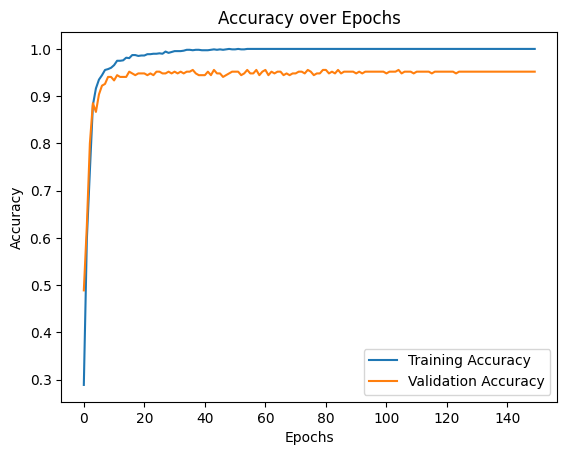

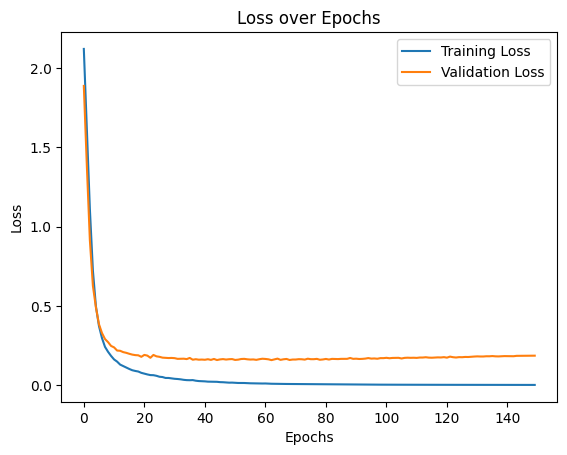

In [9]:
# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Task 2

**Load IMDb dataset**

In [10]:
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Input
from tensorflow.keras.optimizers import SGD

In [11]:
num_words = 8000
maxlen = 200   # fixed sequence length for padding/truncation

(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=num_words)

# Pad sequences so they can be fed into the network
x_train_full = pad_sequences(x_train_full, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("Full training shape:", x_train_full.shape)
print("Test shape:", x_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full training shape: (25000, 200)
Test shape: (25000, 200)


**Split original training set into train/validation (80/20)**

In [12]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", x_train.shape)
print("Validation shape:", x_val.shape)

Train shape: (20000, 200)
Validation shape: (5000, 200)


**Neural network**

In [13]:
model = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=num_words, output_dim=50, input_length=maxlen),
    Flatten(),
    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=SGD(),
    metrics=['accuracy']
)

# Print summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 50)        │       400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │       240,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,049 (2.44 MB)

 Trainable params: 640,049 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

**Model Train**

In [14]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5025 - loss: 0.6930 - val_accuracy: 0.5084 - val_loss: 0.6927
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5309 - loss: 0.6912 - val_accuracy: 0.5128 - val_loss: 0.6925
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5504 - loss: 0.6895 - val_accuracy: 0.5216 - val_loss: 0.6922
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.5698 - loss: 0.6875 - val_accuracy: 0.5312 - val_loss: 0.6913
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5856 - loss: 0.6850 - val_accuracy: 0.5402 - val_loss: 0.6898
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6036 - loss: 0.6812 - val_accuracy: 0.5524 - val_loss: 0.6871
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6194 - loss: 0.6755 - val_accuracy: 0.5718 - val_loss: 0.6830
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6387 - loss: 0.6677 - val_accura

**Evaluate on official test data**

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7600


**Plot training & validation curves**

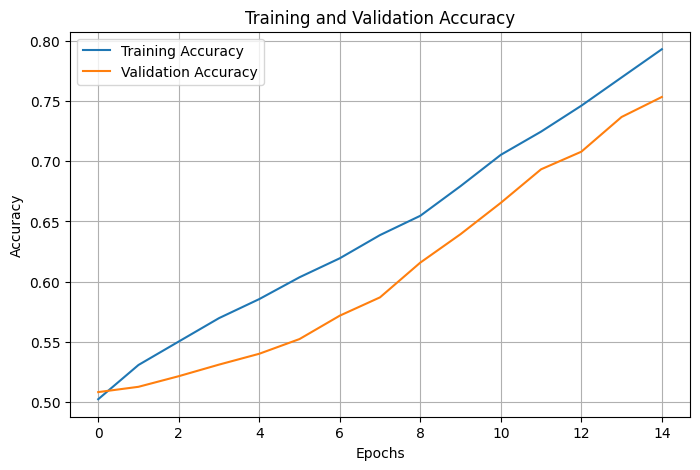

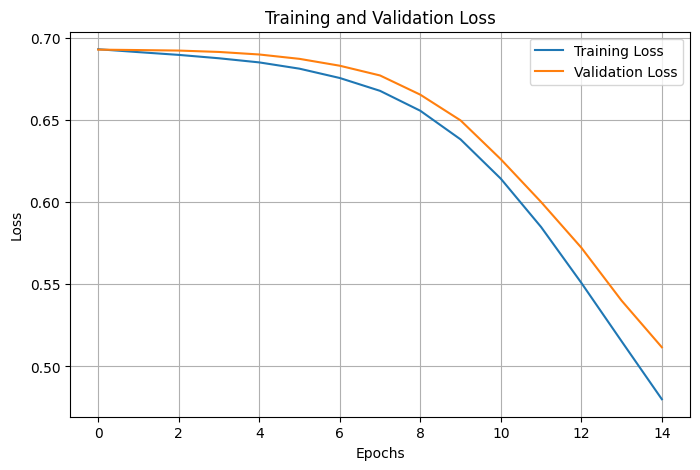

In [16]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**ROC curve and AUC**

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
AUC: 0.8430


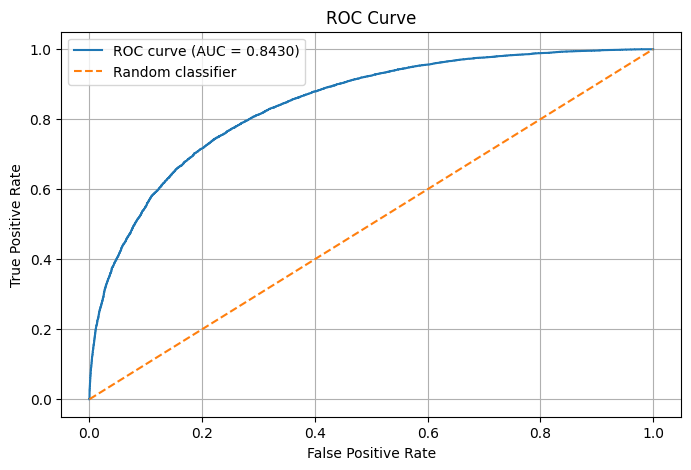

In [17]:
# Predict probabilities on test set
y_prob = model.predict(x_test).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# Task 3

In [18]:
import time
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout

**Loading and preprocessing IMDb data**

In [19]:
VOCAB_SIZE = 8000
MAX_LEN = 200

(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train_full = pad_sequences(x_train_full, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (20000, 200) (20000,)
Validation: (5000, 200) (5000,)
Test: (25000, 200) (25000,)


**Shallow model from Task 2**

In [20]:
shallow_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=50),
    Flatten(),
    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
], name="IMDb_Shallow")

shallow_model.compile(
    optimizer=SGD(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

shallow_model.summary()

Model: "IMDb_Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 50)        │       400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │       240,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,049 (2.44 MB)

 Trainable params: 640,049 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

**Deep model for Task 3**

In [21]:
deep_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    Flatten(),
    Dense(48, activation='relu'),
    Dropout(0.3),
    Dense(24, activation='relu'),
    Dropout(0.2),
    Dense(12, activation='relu'),
    Dense(1, activation='sigmoid')
], name="IMDb_Deep")

deep_model.compile(
    optimizer=SGD(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

Model: "IMDb_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 48)             │       614,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,127,937 (4.30 MB)

 Trainable params: 1,127,937 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

**Helper to train and time a model**

In [22]:
def train_model(model, epochs=15, batch_size=32):
    start_time = time.perf_counter()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    train_time = time.perf_counter() - start_time
    return history, train_time

**Train model**

In [23]:
shallow_history, shallow_time = train_model(shallow_model, epochs=15)
deep_history, deep_time = train_model(deep_model, epochs=15)

print(f"Shallow model training time: {shallow_time:.2f} seconds")
print(f"Deep model training time:    {deep_time:.2f} seconds")

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5069 - loss: 0.6928 - val_accuracy: 0.5100 - val_loss: 0.6924
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5311 - loss: 0.6912 - val_accuracy: 0.5224 - val_loss: 0.6920
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5499 - loss: 0.6896 - val_accuracy: 0.5286 - val_loss: 0.6914
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5682 - loss: 0.6874 - val_accuracy: 0.5388 - val_loss: 0.6904
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5875 - loss: 0.6845 - val_accuracy: 0.5564 - val_loss: 0.6886
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6059 - loss: 0.6803 - val_accuracy: 0.5768 - val_loss: 0.6853
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6300 - loss: 0.6739 - val_accuracy: 0.5886 - val_loss: 0.6795
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6479 - loss: 0.6642 - val_accuracy: 0.

**Evaluate on test data**

In [24]:
shallow_test_loss, shallow_test_acc = shallow_model.evaluate(x_test, y_test, verbose=0)
deep_test_loss, deep_test_acc = deep_model.evaluate(x_test, y_test, verbose=0)

print(f"Shallow test accuracy: {shallow_test_acc:.4f}")
print(f"Deep test accuracy:    {deep_test_acc:.4f}")

Shallow test accuracy: 0.7722
Deep test accuracy:    0.7714


**Confusion matrices**

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


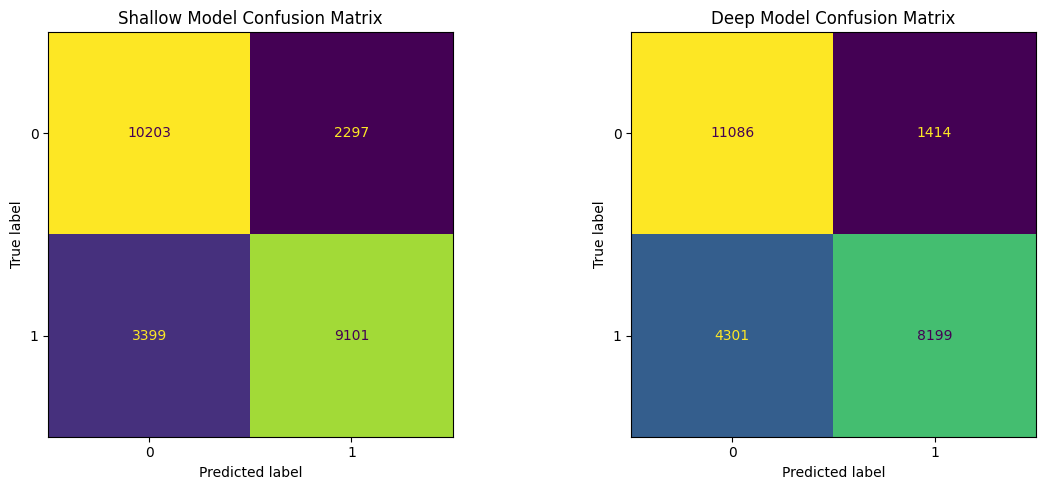

In [25]:
shallow_probs = shallow_model.predict(x_test).ravel()
deep_probs = deep_model.predict(x_test).ravel()

shallow_pred = (shallow_probs >= 0.5).astype(int)
deep_pred = (deep_probs >= 0.5).astype(int)

cm_shallow = confusion_matrix(y_test, shallow_pred)
cm_deep = confusion_matrix(y_test, deep_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_shallow)
disp1.plot(ax=axes[0], values_format='d', colorbar=False)
axes[0].set_title("Shallow Model Confusion Matrix")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_deep)
disp2.plot(ax=axes[1], values_format='d', colorbar=False)
axes[1].set_title("Deep Model Confusion Matrix")

plt.tight_layout()
plt.show()

**Plot training/validation curves**

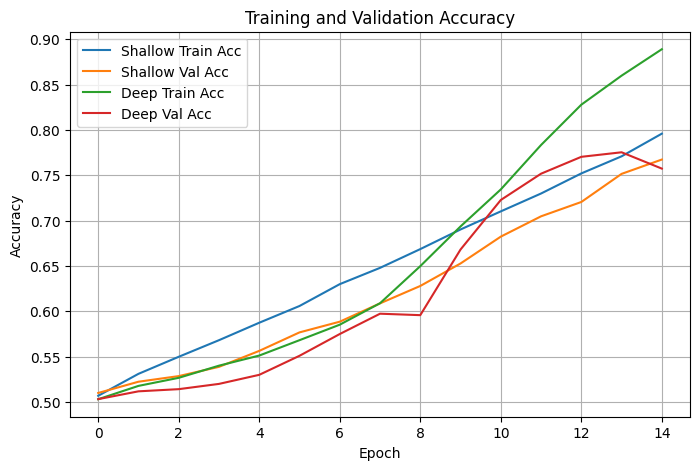

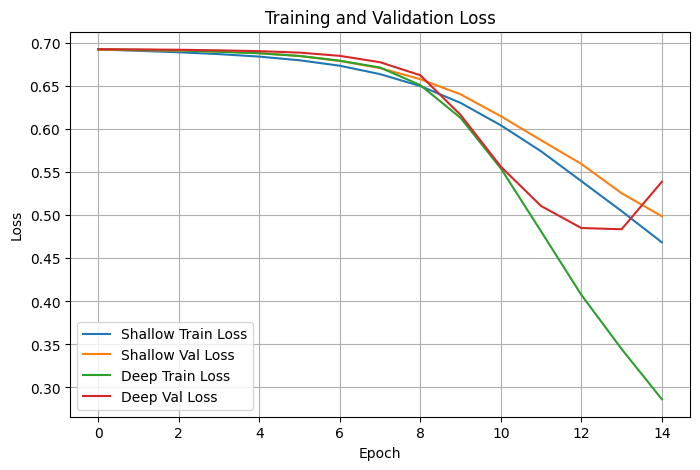

In [26]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(shallow_history.history['accuracy'], label='Shallow Train Acc')
plt.plot(shallow_history.history['val_accuracy'], label='Shallow Val Acc')
plt.plot(deep_history.history['accuracy'], label='Deep Train Acc')
plt.plot(deep_history.history['val_accuracy'], label='Deep Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(shallow_history.history['loss'], label='Shallow Train Loss')
plt.plot(shallow_history.history['val_loss'], label='Shallow Val Loss')
plt.plot(deep_history.history['loss'], label='Deep Train Loss')
plt.plot(deep_history.history['val_loss'], label='Deep Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**Compare overfitting and performance**

In [27]:
shallow_overfit_acc = shallow_history.history['accuracy'][-1] - shallow_history.history['val_accuracy'][-1]
deep_overfit_acc = deep_history.history['accuracy'][-1] - deep_history.history['val_accuracy'][-1]

shallow_overfit_loss = shallow_history.history['val_loss'][-1] - shallow_history.history['loss'][-1]
deep_overfit_loss = deep_history.history['val_loss'][-1] - deep_history.history['loss'][-1]

results = pd.DataFrame({
    "Model": ["Shallow", "Deep"],
    "Train Time (sec)": [shallow_time, deep_time],
    "Test Accuracy": [shallow_test_acc, deep_test_acc],
    "Final Train Acc": [shallow_history.history['accuracy'][-1], deep_history.history['accuracy'][-1]],
    "Final Val Acc": [shallow_history.history['val_accuracy'][-1], deep_history.history['val_accuracy'][-1]],
    "Acc Gap (Train-Val)": [shallow_overfit_acc, deep_overfit_acc],
    "Final Train Loss": [shallow_history.history['loss'][-1], deep_history.history['loss'][-1]],
    "Final Val Loss": [shallow_history.history['val_loss'][-1], deep_history.history['val_loss'][-1]],
    "Loss Gap (Val-Train)": [shallow_overfit_loss, deep_overfit_loss],
})

print(results)

     Model  Train Time (sec)  Test Accuracy  Final Train Acc  Final Val Acc  \
0  Shallow         81.638390        0.77216          0.79595         0.7674   
1     Deep        122.452062        0.77140          0.88905         0.7574   

   Acc Gap (Train-Val)  Final Train Loss  Final Val Loss  Loss Gap (Val-Train)  
0              0.02855          0.468668        0.499012              0.030344  
1              0.13165          0.286296        0.539041              0.252745  


**Simple conclusion helper**

In [28]:
better_model = "Deep" if deep_test_acc > shallow_test_acc else "Shallow"
print(f"Better overall test accuracy: {better_model} model")

Better overall test accuracy: Shallow model


# Task 4

**Comparing learning rates 0.01 vs 0.0001 using the same setup as Problem 3**

In [29]:
# Loading and preprocessing IMDb data

VOCAB_SIZE = 8000
MAX_LEN = 200

(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train_full = pad_sequences(x_train_full, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (20000, 200) (20000,)
Validation: (5000, 200) (5000,)
Test: (25000, 200) (25000,)


In [30]:
# Deep model

def build_model(learning_rate):
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(input_dim=VOCAB_SIZE, output_dim=64),
        Flatten(),
        Dense(48, activation='relu'),
        Dropout(0.3),
        Dense(24, activation='relu'),
        Dropout(0.2),
        Dense(12, activation='relu'),
        Dense(1, activation='sigmoid')
    ], name=f"IMDb_Deep_lr_{learning_rate}")

    model.compile(
        optimizer=SGD(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [31]:
# Train helper

def train_model(model, epochs=15, batch_size=32):
    start = time.perf_counter()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    train_time = time.perf_counter() - start
    return history, train_time

In [32]:
# Train models with two learning rates

lr1 = 0.01
lr2 = 0.0001

model_lr1 = build_model(lr1)
model_lr2 = build_model(lr2)

model_lr1.summary()
model_lr2.summary()

history_lr1, time_lr1 = train_model(model_lr1, epochs=15)
history_lr2, time_lr2 = train_model(model_lr2, epochs=15)

Model: "IMDb_Deep_lr_0.01"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 48)             │       614,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,127,937 (4.30 MB)

 Trainable params: 1,127,937 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 64)        │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 48)             │       614,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,127,937 (4.30 MB)

 Trainable params: 1,127,937 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4976 - loss: 0.6933 - val_accuracy: 0.5168 - val_loss: 0.6930
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5001 - loss: 0.6931 - val_accuracy: 0.5140 - val_loss: 0.6930
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5070 - loss: 0.6929 - val_accuracy: 0.5128 - val_loss: 0.6930
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5179 - loss: 0.6926 - val_accuracy: 0.5138 - val_loss: 0.6928
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5272 - loss: 0.6921 - val_accuracy: 0.5184 - val_loss: 0.6926
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5332 - loss: 0.6913 - val_accuracy: 0.5226 - val_loss: 0.6921
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5387 - loss: 0.6900 - val_accuracy: 0.5306 - val_loss: 0.6915
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5487 - loss: 0.6883 - val_accu

In [33]:
# Evaluate on test data

loss_lr1, acc_lr1 = model_lr1.evaluate(x_test, y_test, verbose=0)
loss_lr2, acc_lr2 = model_lr2.evaluate(x_test, y_test, verbose=0)

print(f"LR={lr1} -> Test Accuracy: {acc_lr1:.4f}, Test Loss: {loss_lr1:.4f}, Train Time: {time_lr1:.2f}s")
print(f"LR={lr2} -> Test Accuracy: {acc_lr2:.4f}, Test Loss: {loss_lr2:.4f}, Train Time: {time_lr2:.2f}s")

LR=0.01 -> Test Accuracy: 0.7426, Test Loss: 0.5205, Train Time: 119.76s
LR=0.0001 -> Test Accuracy: 0.5086, Test Loss: 0.6930, Train Time: 120.17s


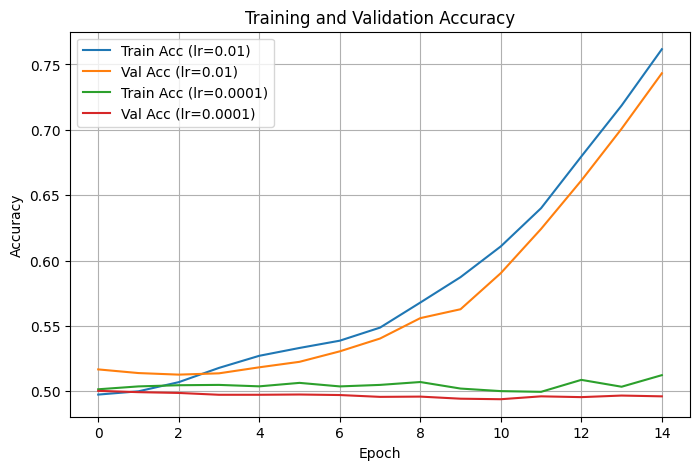

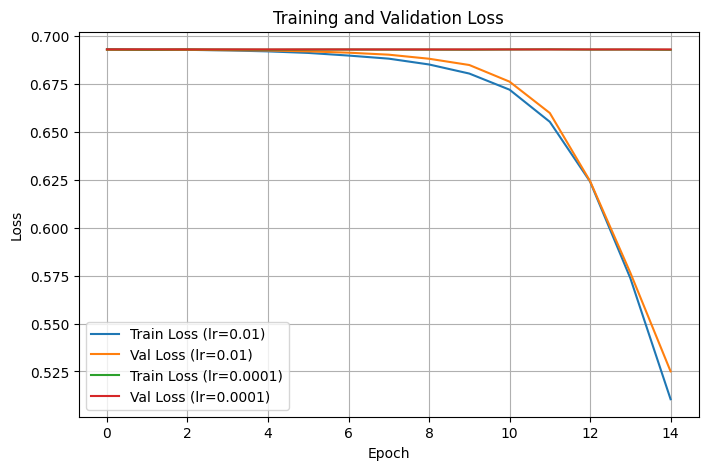

In [34]:
# Plot training and validation curves

plt.figure(figsize=(8, 5))
plt.plot(history_lr1.history['accuracy'], label=f'Train Acc (lr={lr1})')
plt.plot(history_lr1.history['val_accuracy'], label=f'Val Acc (lr={lr1})')
plt.plot(history_lr2.history['accuracy'], label=f'Train Acc (lr={lr2})')
plt.plot(history_lr2.history['val_accuracy'], label=f'Val Acc (lr={lr2})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_lr1.history['loss'], label=f'Train Loss (lr={lr1})')
plt.plot(history_lr1.history['val_loss'], label=f'Val Loss (lr={lr1})')
plt.plot(history_lr2.history['loss'], label=f'Train Loss (lr={lr2})')
plt.plot(history_lr2.history['val_loss'], label=f'Val Loss (lr={lr2})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


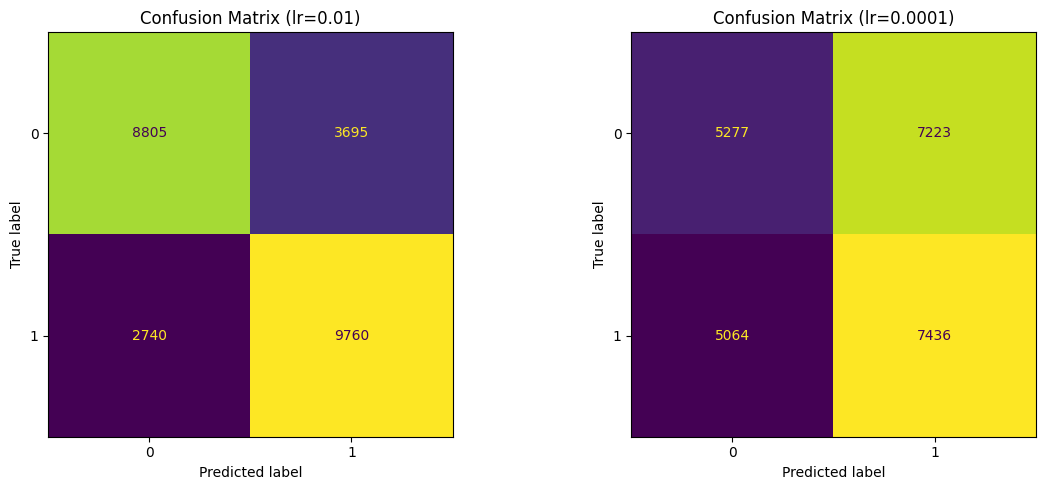

In [35]:
# Confusion matrices

pred_lr1 = (model_lr1.predict(x_test).ravel() >= 0.5).astype(int)
pred_lr2 = (model_lr2.predict(x_test).ravel() >= 0.5).astype(int)

cm_lr1 = confusion_matrix(y_test, pred_lr1)
cm_lr2 = confusion_matrix(y_test, pred_lr2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_lr1).plot(ax=axes[0], values_format='d', colorbar=False)
axes[0].set_title(f'Confusion Matrix (lr={lr1})')

ConfusionMatrixDisplay(cm_lr2).plot(ax=axes[1], values_format='d', colorbar=False)
axes[1].set_title(f'Confusion Matrix (lr={lr2})')

plt.tight_layout()
plt.show()

In [36]:
# Compare results in a table

results = pd.DataFrame({
    "Learning Rate": [lr1, lr2],
    "Train Time (sec)": [time_lr1, time_lr2],
    "Test Accuracy": [acc_lr1, acc_lr2],
    "Test Loss": [loss_lr1, loss_lr2],
    "Final Train Acc": [history_lr1.history['accuracy'][-1], history_lr2.history['accuracy'][-1]],
    "Final Val Acc": [history_lr1.history['val_accuracy'][-1], history_lr2.history['val_accuracy'][-1]],
    "Accuracy Gap": [
        history_lr1.history['accuracy'][-1] - history_lr1.history['val_accuracy'][-1],
        history_lr2.history['accuracy'][-1] - history_lr2.history['val_accuracy'][-1]
    ],
    "Final Train Loss": [history_lr1.history['loss'][-1], history_lr2.history['loss'][-1]],
    "Final Val Loss": [history_lr1.history['val_loss'][-1], history_lr2.history['val_loss'][-1]],
})

print(results)

   Learning Rate  Train Time (sec)  Test Accuracy  Test Loss  Final Train Acc  \
0         0.0100        119.760360        0.74260   0.520527           0.7616   
1         0.0001        120.166316        0.50856   0.693035           0.5124   

   Final Val Acc  Accuracy Gap  Final Train Loss  Final Val Loss  
0         0.7432        0.0184          0.510498        0.525041  
1         0.4962        0.0162          0.692947        0.693144  


In [37]:
# Simple conclusion

better = lr1 if acc_lr1 > acc_lr2 else lr2
print(f"Better test accuracy: learning rate = {better}")

Better test accuracy: learning rate = 0.01
